# 🇨🇳 China CDC Weekly Surveillance Data

This notebook demonstrates how to access disease surveillance data from China CDC Weekly, the official publication of the Chinese Center for Disease Control and Prevention.

**Data Sources:**
- **Notifiable Diseases** - 38 categories (Class A, B, C)
- **Influenza Surveillance** - ILI% and virus detection
- **Weekly Reports** - Epidemiological summaries
- **COVID-19 Updates** - Weekly surveillance
- **Vaccination Coverage** - National immunization data

**Requirements:**
```bash
pip install pandas matplotlib seaborn requests beautifulsoup4
```

## 1. Setup and Imports

In [1]:
import sys
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Add the scripts directory to path
sys.path.insert(0, '../../scripts')

# Import China CDC accessor
from accessors.china_cdc import ChinaCDCAccessor

print("✅ Imports completed successfully!")
print(f"⏰ Current time: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ Imports completed successfully!
⏰ Current time: 2026-03-20 11:22


## 2. Initialize China CDC Accessor

In [2]:
# Initialize the China CDC accessor
ccdc = ChinaCDCAccessor()

print("🇨🇳 China CDC Weekly Accessor initialized")
print(f"Base URL: {ccdc.BASE_URL}")
print(f"CNIC URL: {ccdc.CNIC_URL}")

🇨🇳 China CDC Weekly Accessor initialized
Base URL: http://weekly.chinacdc.cn
CNIC URL: http://www.chinacdc.cn/cnic


## 3. Explore Chinese Provinces


🇨🇳 Chinese Provinces and Municipalities (31 total):
province_code province_name_en province_name_cn
           BJ          Beijing              北京市
           TJ          Tianjin              天津市
           HE            Hebei              河北省
           SX           Shanxi              山西省
           NM   Inner Mongolia           内蒙古自治区
           LN         Liaoning              辽宁省
           JL            Jilin              吉林省
           HL     Heilongjiang             黑龙江省
           SH         Shanghai              上海市
           JS          Jiangsu              江苏省


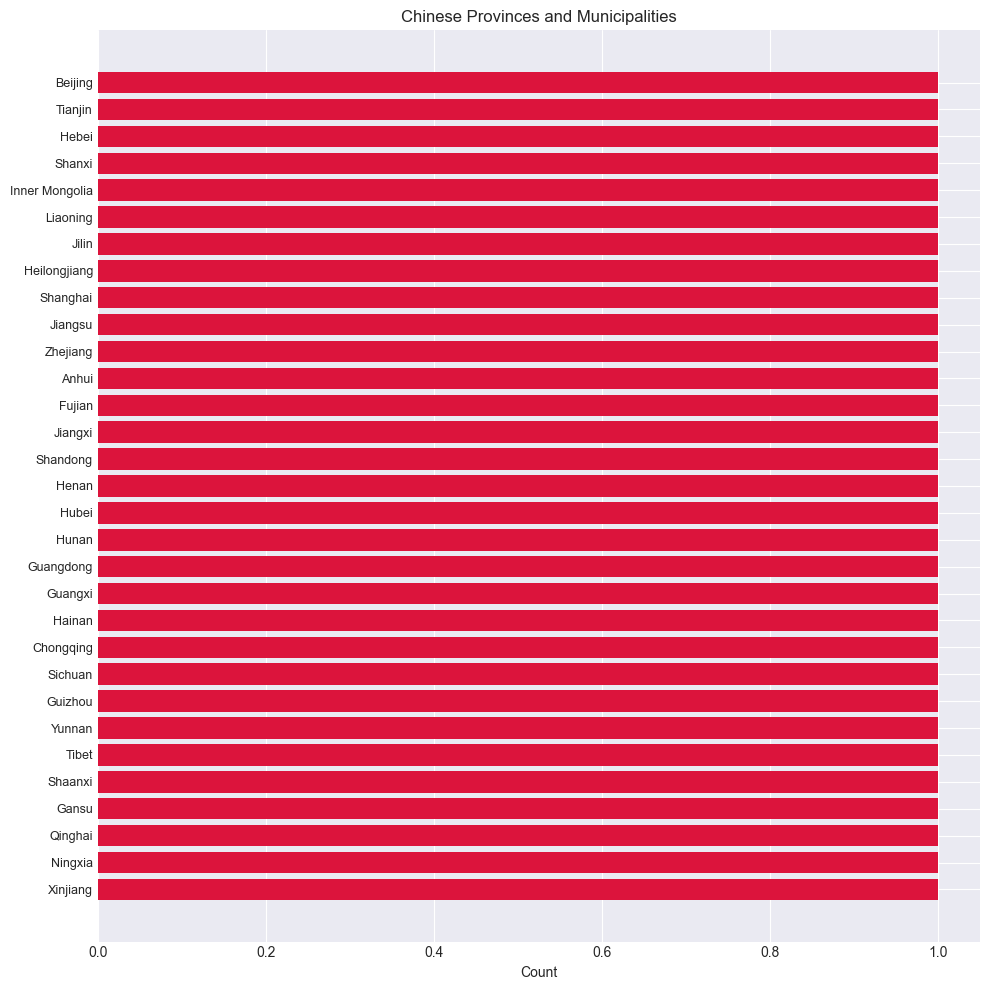

In [3]:
# List Chinese provinces and municipalities
provinces = ccdc.list_provinces()
print(f"\n🇨🇳 Chinese Provinces and Municipalities ({len(provinces)} total):")
print(provinces.head(10).to_string(index=False))

# Visualize provinces
fig, ax = plt.subplots(figsize=(10, 10))
y_pos = range(len(provinces))
ax.barh(y_pos, [1]*len(provinces), color='crimson')
ax.set_yticks(y_pos)
ax.set_yticklabels(provinces['province_name_en'], fontsize=9)
ax.set_xlabel('Count')
ax.set_title('Chinese Provinces and Municipalities')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Explore Notifiable Disease Categories


🦠 Notifiable Diseases (39 total):

📊 Disease Categories:
  Class B: 26 diseases
  Class C: 11 diseases
  Class A: 2 diseases

📋 Sample Diseases by Category:

Class A:
  • Plague (鼠疫)
  • Cholera (霍乱)

Class B:
  • SARS (传染性非典型肺炎)
  • AIDS (艾滋病)
  • Viral_Hepatitis (病毒性肝炎)
  • Polio (脊髓灰质炎)
  • Human_Avian_Influenza (人感染高致病性禽流感)

Class C:
  • Influenza (流行性感冒)
  • Mumps (流行性腮腺炎)
  • Rubella (风疹)
  • Acute_Hemorrhagic_Conjunctivitis (急性出血性结膜炎)
  • Leprosy (麻风病)


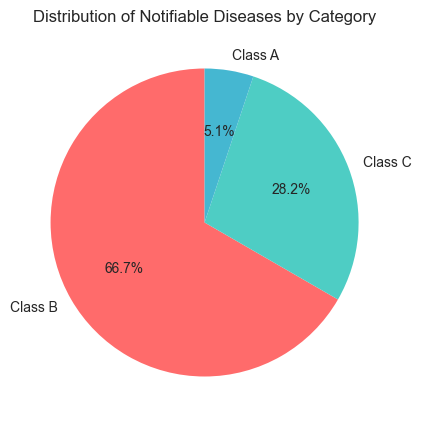

In [5]:
# List notifiable infectious diseases
diseases = ccdc.list_notifiable_diseases()
print(f"\n🦠 Notifiable Diseases ({len(diseases)} total):")

# Count by category
category_counts = diseases['category'].value_counts()
print("\n📊 Disease Categories:")
for cat, count in category_counts.items():
    print(f"  {cat}: {count} diseases")

# Visualize categories
fig, ax1 = plt.subplots(1, 1, figsize=(14, 5))

# Pie chart of categories
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
ax1.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
ax1.set_title('Distribution of Notifiable Diseases by Category')

# Sample diseases by category
print("\n📋 Sample Diseases by Category:")
for category in ['Class A', 'Class B', 'Class C']:
    cat_diseases = diseases[diseases['category'] == category].head(5)
    print(f"\n{category}:")
    for _, row in cat_diseases.iterrows():
        print(f"  • {row['disease_code']} ({row['disease_name_cn']})")

## 5. Fetch Weekly Reports Metadata

In [6]:
# Get weekly reports metadata for current year
current_year = datetime.now().year
print(f"📰 Fetching weekly reports metadata for {current_year}...")

weekly_reports = ccdc.get_weekly_reports(year=current_year)
print(f"✅ Retrieved {len(weekly_reports)} weekly report entries")

# Show sample reports
print("\n🔍 Sample Weekly Reports:")
print(weekly_reports[['year', 'week', 'doi', 'url']].head())

# Show structure
print(f"\n📋 Available columns: {list(weekly_reports.columns)}")

INFO:accessors.china_cdc:Fetching weekly reports for year 2026, week=None


📰 Fetching weekly reports metadata for 2026...
✅ Retrieved 52 weekly report entries

🔍 Sample Weekly Reports:
   year  week                    doi  \
0  2026     1  10.46234/ccdcw2026001   
1  2026     2  10.46234/ccdcw2026002   
2  2026     3  10.46234/ccdcw2026003   
3  2026     4  10.46234/ccdcw2026004   
4  2026     5  10.46234/ccdcw2026005   

                                                 url  
0  http://weekly.chinacdc.cn/en/article/doi/10.46...  
1  http://weekly.chinacdc.cn/en/article/doi/10.46...  
2  http://weekly.chinacdc.cn/en/article/doi/10.46...  
3  http://weekly.chinacdc.cn/en/article/doi/10.46...  
4  http://weekly.chinacdc.cn/en/article/doi/10.46...  

📋 Available columns: ['year', 'week', 'doi', 'url', 'title_en', 'title_cn', 'publication_date', 'data_available', 'note']


## 6. Query Notifiable Diseases Data

In [7]:
# Query specific diseases
selected_diseases = ['Influenza', 'Dengue', 'COVID_19']
selected_provinces = ['GD', 'BJ', 'SH']  # Guangdong, Beijing, Shanghai

print(f"🔍 Querying disease data:")
print(f"  Diseases: {', '.join(selected_diseases)}")
print(f"  Provinces: {', '.join(selected_provinces)}")

disease_data = ccdc.get_notifiable_diseases(
    diseases=selected_diseases,
    provinces=selected_provinces,
    date_range=('2024-01-01', '2024-12-31')
)

if not disease_data.empty:
    print(f"\n✅ Retrieved {len(disease_data)} records")
    print("\n🔍 Sample data:")
    print(disease_data.head())
    
    # Show data structure
    print(f"\n📋 Columns: {list(disease_data.columns)}")
else:
    print("\n⚠️ Note: Detailed disease data requires parsing China CDC Weekly PDFs")
    print("   Weekly reports available at: http://weekly.chinacdc.cn/")

INFO:accessors.china_cdc:Fetching notifiable disease data: diseases=['Influenza', 'Dengue', 'COVID_19'], provinces=['GD', 'BJ', 'SH']


🔍 Querying disease data:
  Diseases: Influenza, Dengue, COVID_19
  Provinces: GD, BJ, SH

✅ Retrieved 9 records

🔍 Sample data:
  disease_code disease_name_cn disease_category province_code province_name  \
0    Influenza           流行性感冒          Class C            GD     Guangdong   
1    Influenza           流行性感冒          Class C            BJ       Beijing   
2    Influenza           流行性感冒          Class C            SH      Shanghai   
3       Dengue             登革热          Class B            GD     Guangdong   
4       Dengue             登革热          Class B            BJ       Beijing   

  cases deaths        date       data_source  \
0  None   None  2024-01-01  China CDC Weekly   
1  None   None  2024-01-01  China CDC Weekly   
2  None   None  2024-01-01  China CDC Weekly   
3  None   None  2024-01-01  China CDC Weekly   
4  None   None  2024-01-01  China CDC Weekly   

                                  note  
0  Data requires weekly report parsing  
1  Data requires weekly re

## 7. Influenza Surveillance

INFO:accessors.china_cdc:Fetching influenza surveillance for year=2024, weeks=52


🤧 Fetching influenza surveillance data...
✅ Retrieved 52 weekly ILI records

🔍 Sample data:
   year  week ili_percent ili_cases total_outpatients virus_detected ah3n2  \
0  2024     1        None      None              None           None  None   
1  2024     2        None      None              None           None  None   
2  2024     3        None      None              None           None  None   
3  2024     4        None      None              None           None  None   
4  2024     5        None      None              None           None  None   
5  2024     6        None      None              None           None  None   
6  2024     7        None      None              None           None  None   
7  2024     8        None      None              None           None  None   
8  2024     9        None      None              None           None  None   
9  2024    10        None      None              None           None  None   

   h1n1 b_victoria b_yamagata              data_s

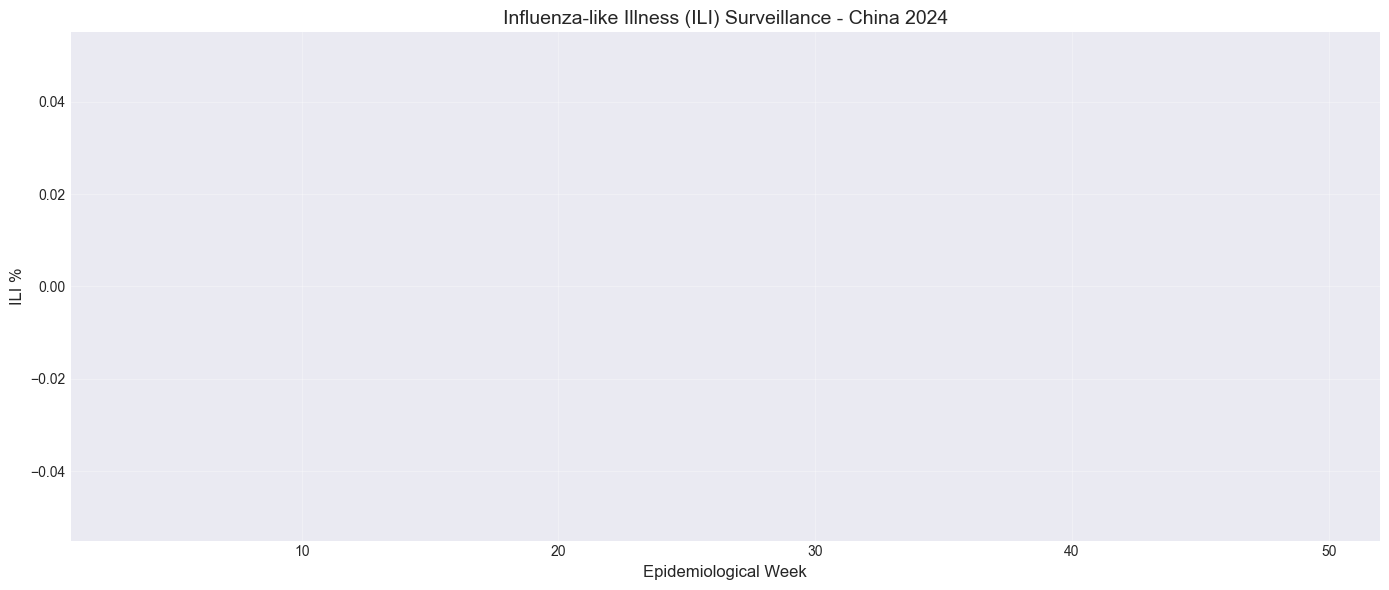

In [8]:
# Fetch influenza surveillance data
print("🤧 Fetching influenza surveillance data...")

flu_data = ccdc.get_influenza_surveillance(
    weeks=list(range(1, 53)),
    year=2024
)

if not flu_data.empty:
    print(f"✅ Retrieved {len(flu_data)} weekly ILI records")
    print("\n🔍 Sample data:")
    print(flu_data.head(10))
    
    # Visualize ILI trend
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(flu_data['week'], flu_data['ili_percent'], 
            linewidth=2, color='orange', marker='o', markersize=4)
    ax.set_xlabel('Epidemiological Week', fontsize=12)
    ax.set_ylabel('ILI %', fontsize=12)
    ax.set_title('Influenza-like Illness (ILI) Surveillance - China 2024', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, 52)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ ILI data requires parsing weekly reports")
    print("   CNIC provides additional data at: http://www.chinacdc.cn/cnic/")

## 8. COVID-19 Updates

In [9]:
# Fetch COVID-19 updates
print("😷 Fetching COVID-19 updates...")

covid_data = ccdc.get_covid_updates(
    date_range=('2024-01-01', '2024-12-31')
)

if not covid_data.empty:
    print(f"✅ Retrieved {len(covid_data)} COVID-19 records")
    print("\n🔍 Sample data:")
    print(covid_data.head())
else:
    print("\n⚠️ COVID-19 data requires parsing China CDC Weekly reports")
    print("   Visit: http://weekly.chinacdc.cn/")

INFO:accessors.china_cdc:Fetching COVID-19 updates


😷 Fetching COVID-19 updates...
✅ Retrieved 1 COVID-19 records

🔍 Sample data:
   date new_cases new_deaths active_cases severe_cases       data_source  \
0  None      None       None         None         None  China CDC Weekly   

                                           note  
0  COVID-19 data requires weekly report parsing  


## 9. Vaccination Coverage

In [10]:
# Fetch vaccination coverage data
vaccines = ['EPI', 'COVID-19']
print(f"💉 Fetching vaccination coverage for: {', '.join(vaccines)}")

vacc_data = ccdc.get_vaccination_coverage(
    vaccines=vaccines,
    year=2024
)

if not vacc_data.empty:
    print(f"✅ Retrieved {len(vacc_data)} vaccination records")
    print("\n🔍 Sample data:")
    print(vacc_data)
else:
    print("\n⚠️ Vaccination data requires report parsing")

INFO:accessors.china_cdc:Fetching vaccination coverage for ['EPI', 'COVID-19'], year=2024


💉 Fetching vaccination coverage for: EPI, COVID-19
✅ Retrieved 2 vaccination records

🔍 Sample data:
    vaccine  year coverage_percent doses_administered_millions  \
0       EPI  2024             None                        None   
1  COVID-19  2024             None                        None   

  target_population_millions       data_source  \
0                       None  China CDC Weekly   
1                       None  China CDC Weekly   

                                       note  
0  Vaccination data requires report parsing  
1  Vaccination data requires report parsing  


## 10. Annual Disease Summary

INFO:accessors.china_cdc:Generating disease summary for 2024


📊 Generating annual disease summary...
✅ Generated summary for 10 diseases

🔍 Sample summary:
              disease_code disease_name_cn category  year total_cases total_deaths      data_source                              note
                    Plague              鼠疫  Class A  2024        None         None China CDC Weekly Summary requires data aggregation
                   Cholera              霍乱  Class A  2024        None         None China CDC Weekly Summary requires data aggregation
                      SARS        传染性非典型肺炎  Class B  2024        None         None China CDC Weekly Summary requires data aggregation
                      AIDS             艾滋病  Class B  2024        None         None China CDC Weekly Summary requires data aggregation
           Viral_Hepatitis           病毒性肝炎  Class B  2024        None         None China CDC Weekly Summary requires data aggregation
                     Polio           脊髓灰质炎  Class B  2024        None         None China CDC Weekly Su

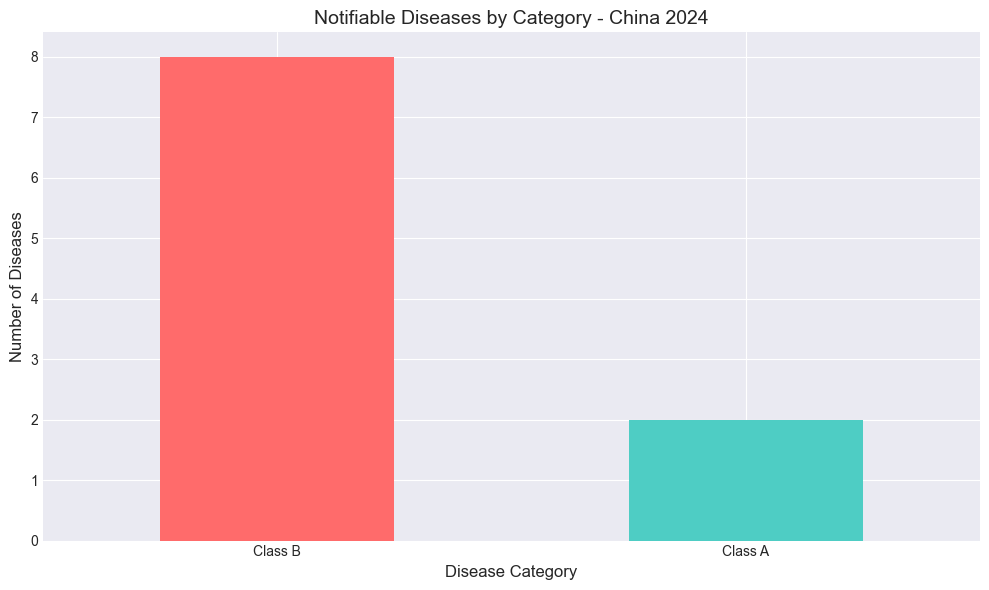

In [11]:
# Get annual summary
print("📊 Generating annual disease summary...")

summary = ccdc.get_summary_by_disease(year=2024)

if not summary.empty:
    print(f"✅ Generated summary for {len(summary)} diseases")
    print("\n🔍 Sample summary:")
    print(summary.head(10).to_string(index=False))
    
    # Visualize by category
    fig, ax = plt.subplots(figsize=(10, 6))
    cat_counts = summary['category'].value_counts()
    cat_counts.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax.set_xlabel('Disease Category', fontsize=12)
    ax.set_ylabel('Number of Diseases', fontsize=12)
    ax.set_title('Notifiable Diseases by Category - China 2024', fontsize=14)
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

## 11. Summary Dashboard

In [12]:
# Create a summary dashboard
print("="*60)
print("🇨🇳 CHINA CDC WEEKLY SURVEILLANCE DATA SUMMARY")
print("="*60)

print("\n🌏 Coverage:")
print(f"  • Provinces/Municipalities: {len(ccdc.PROVINCES)}")
print(f"  • Notifiable Diseases: {len(ccdc.NOTIFIABLE_DISEASES)}")
print(f"  • Disease Categories: Class A (2), Class B (27), Class C (9)")

print("\n🦠 Class A Diseases (Most Severe):")
class_a = diseases[diseases['category'] == 'Class A']
for _, row in class_a.iterrows():
    print(f"  • {row['disease_code']}: {row['disease_name_cn']}")

print("\n📈 Data Sources:")
print(f"  • Weekly Reports: {ccdc.BASE_URL}")
print(f"  • Influenza Center: {ccdc.CNIC_URL}")

print("\n💡 Usage Examples:")
print("  ccdc = ChinaCDCAccessor()")
print("  diseases = ccdc.get_notifiable_diseases(")
print("      diseases=['Influenza', 'Dengue'],")
print("      provinces=['GD', 'BJ'],")
print("      date_range=('2024-01-01', '2024-12-31')")
print("  )")
print("  flu = ccdc.get_influenza_surveillance(weeks=range(1, 53))")
print("  reports = ccdc.get_weekly_reports(year=2024)")

print("\n✅ China CDC accessor ready to use!")
print("="*60)

🇨🇳 CHINA CDC WEEKLY SURVEILLANCE DATA SUMMARY

🌏 Coverage:
  • Provinces/Municipalities: 31
  • Notifiable Diseases: 39
  • Disease Categories: Class A (2), Class B (27), Class C (9)

🦠 Class A Diseases (Most Severe):
  • Plague: 鼠疫
  • Cholera: 霍乱

📈 Data Sources:
  • Weekly Reports: http://weekly.chinacdc.cn
  • Influenza Center: http://www.chinacdc.cn/cnic

💡 Usage Examples:
  ccdc = ChinaCDCAccessor()
  diseases = ccdc.get_notifiable_diseases(
      diseases=['Influenza', 'Dengue'],
      provinces=['GD', 'BJ'],
      date_range=('2024-01-01', '2024-12-31')
  )
  flu = ccdc.get_influenza_surveillance(weeks=range(1, 53))
  reports = ccdc.get_weekly_reports(year=2024)

✅ China CDC accessor ready to use!


## 12. Data Export

In [ ]:
# Export data to CSV (optional)
export_path = "./china_cdc_export/"
import os
os.makedirs(export_path, exist_ok=True)

# Export provinces
provinces.to_csv(f"{export_path}china_provinces.csv", index=False)
print(f"✅ Exported provinces to {export_path}china_provinces.csv")

# Export diseases
diseases.to_csv(f"{export_path}china_notifiable_diseases.csv", index=False)
print(f"✅ Exported diseases to {export_path}china_notifiable_diseases.csv")

# Export weekly reports metadata
if not weekly_reports.empty:
    weekly_reports.to_csv(f"{export_path}weekly_reports.csv", index=False)
    print(f"✅ Exported weekly reports to {export_path}weekly_reports.csv")

print(f"\n📁 All exports saved to: {os.path.abspath(export_path)}")